In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
#from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
import pickle

In [50]:
warnings.filterwarnings('ignore')

In [51]:
df=pd.read_csv("loan_approved.csv")

In [52]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [53]:
df.tail

<bound method NDFrame.tail of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849            

In [54]:
df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [55]:
df.describe

<bound method NDFrame.describe of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849        

In [56]:
df.describe(include='O')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status (Approved)
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [57]:
pip install --upgrade pip

<Axes: ylabel='LoanAmount'>

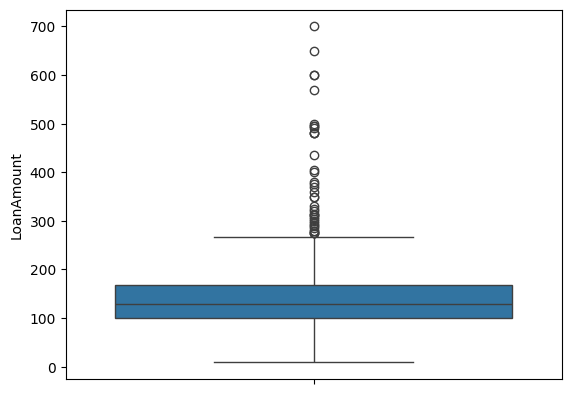

In [58]:
sns.boxplot(df.LoanAmount)

<Axes: ylabel='ApplicantIncome'>

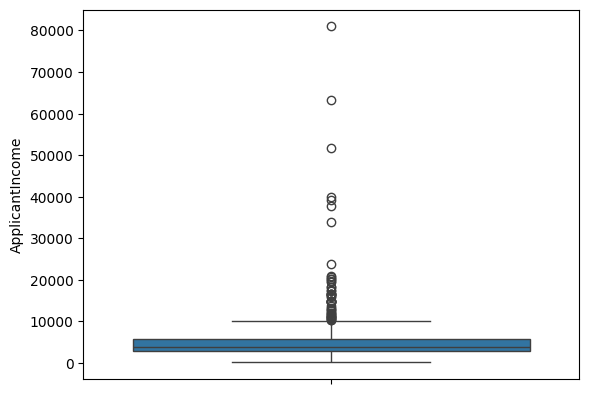

In [59]:
sns.boxplot(df.ApplicantIncome)

<Axes: ylabel='Credit_History'>

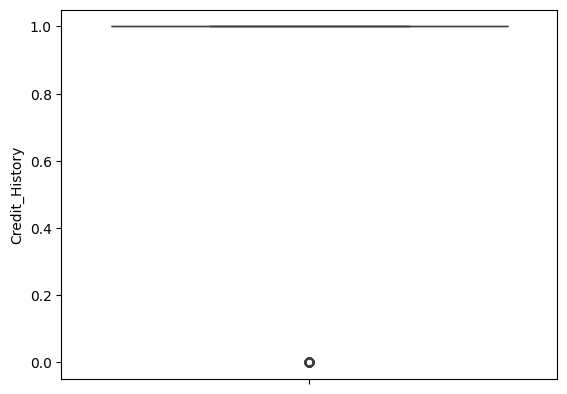

In [60]:
sns.boxplot(df.Credit_History)

<Axes: ylabel='CoapplicantIncome'>

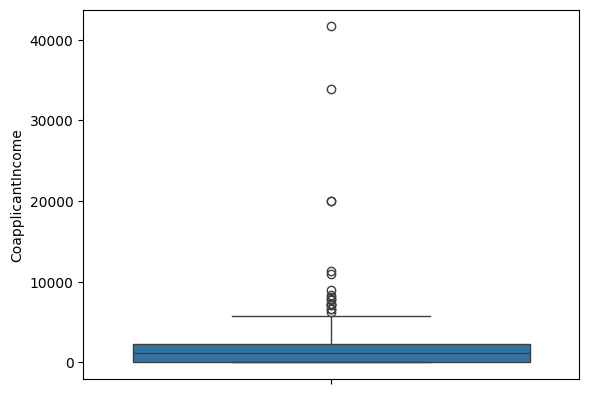

In [61]:
sns.boxplot(df.CoapplicantIncome)

In [62]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [63]:
df.loc[df['Gender'].isnull(),'Gender']= df.Gender.unique()[0]
df.loc[df['Married'].isnull(),'Married']= df.Married.unique()[0]
df.loc[df['Dependents'].isnull(),'Dependents']= '0'
df.loc[df['Self_Employed'].isnull(),'Self_Employed']= df.Self_Employed.unique()[0]
df.loc[df['LoanAmount'].isnull(),'LoanAmount']= df.LoanAmount.mean()
df.loc[df['Loan_Amount_Term'].isnull(),'Loan_Amount_Term']= df.Loan_Amount_Term.unique()[0]
df.loc[df['Credit_History'].isnull(),'Credit_History']= df.Credit_History.unique()[0]

In [64]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

<Axes: ylabel='LoanAmount'>

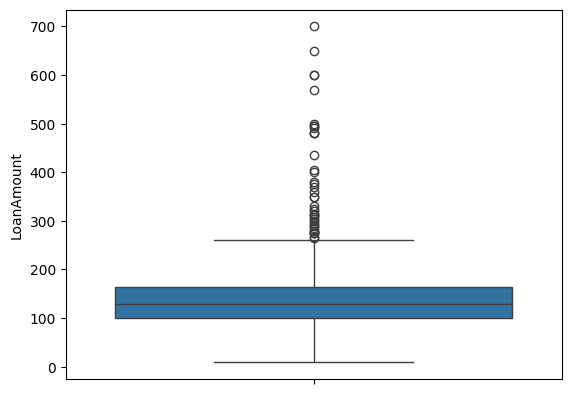

In [65]:
sns.boxplot(df.LoanAmount)

<Axes: ylabel='ApplicantIncome'>

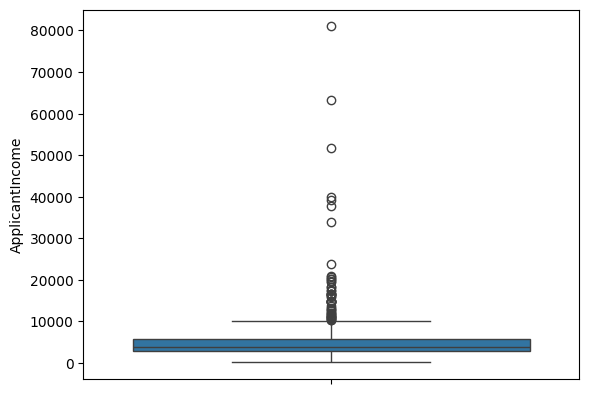

In [66]:
sns.boxplot(df.ApplicantIncome)

<Axes: ylabel='CoapplicantIncome'>

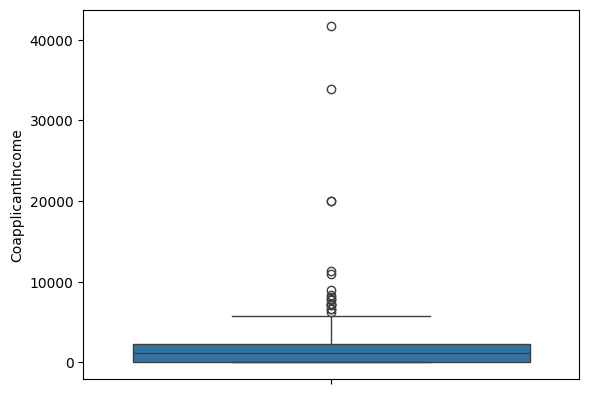

In [67]:
sns.boxplot(df.CoapplicantIncome)

<Axes: >

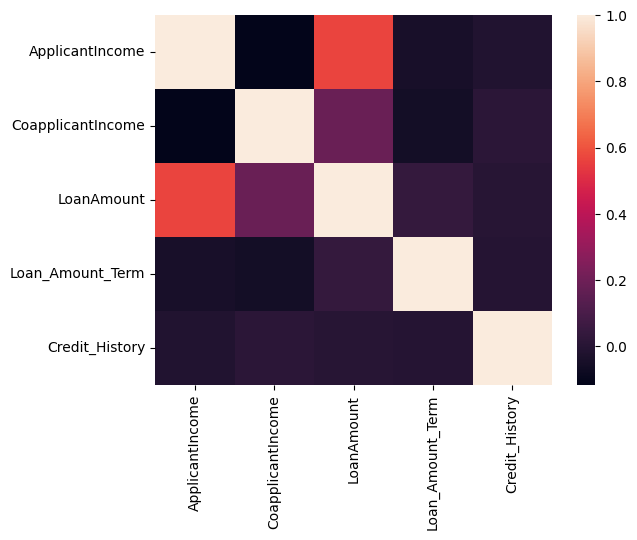

In [68]:
sns.heatmap(df.select_dtypes(include=['int','float']).corr())

In [69]:
df.Credit_History.unique()

array([1., 0.])

In [70]:
OHE_col=['Self_Employed','Property_Area','Gender']
ss_col=['ApplicantIncome','CoapplicantIncome','LoanAmount']
function_transformer_col=['Loan_Amount_Term']
pass_through_col=['Credit_History']
dependents_enc=OrdinalEncoder(categories=[['0','1','2','3+']])
education_enc=OrdinalEncoder(categories=[['Not Graduate','Graduate']])
OE=['Married']

In [71]:
def div_by_30(x):
    return x/30
custom = FunctionTransformer(div_by_30)

In [72]:
def same(x):
    return x
passthru = FunctionTransformer(same)

In [73]:
preprocessor = ColumnTransformer([('OHE',OneHotEncoder(),OHE_col),
                                  ('SS',StandardScaler(),ss_col),
                                  ('FT',custom,function_transformer_col),
                                  ('OE',OrdinalEncoder(),OE),
                                  ('do_nothing',passthru,pass_through_col),
                                  ('OE1',dependents_enc,['Dependents']),
                                  ('OE2',education_enc,['Education']),
                                  ])

In [74]:
preprocessor

ColumnTransformer(transformers=[('OHE', OneHotEncoder(),
                                 ['Self_Employed', 'Property_Area', 'Gender']),
                                ('SS', StandardScaler(),
                                 ['ApplicantIncome', 'CoapplicantIncome',
                                  'LoanAmount']),
                                ('FT',
                                 FunctionTransformer(func=<function div_by_30 at 0x0000019C074F1BC0>),
                                 ['Loan_Amount_Term']),
                                ('OE', OrdinalEncoder(), ['Married']),
                                ('do_nothing',
                                 FunctionTransformer(func=<function same at 0x0000019C074F1E40>),
                                 ['Credit_History']),
                                ('OE1',
                                 OrdinalEncoder(categories=[['0', '1', '2',
                                                             '3+']]),
                                 ['Dependents']),
                                ('OE2',
                                 OrdinalEncoder(categories=[['Not Graduate',
                                                             'Graduate']]),
                                 ['Education'])])

In [75]:
with open('SVM_CT.pkl','wb') as f:
    pickle.dump(preprocessor,f)

In [76]:
with open('Processed_data.pkl','wb')as f:
    pickle.dump(df,f)